# Half Marathon — Training Pipeline

In [26]:
import pandas as pd
from io import BytesIO
import boto3
from dotenv import load_dotenv
import os  
import pandas as pd
from itables import init_notebook_mode
init_notebook_mode(all_interactive=True)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pycaret.regression import setup
import scipy.stats as stats

## Konfiguracja Digital Ocean Spaces

In [28]:
import itables.options as opt

# Zezwolenie na renderowanie HTML w tabelach
opt.allow_html = True

## Wczytuj|emy dane z DigitalOcean

In [2]:
load_dotenv()

True

In [3]:
client = boto3.client('s3',
                      endpoint_url=os.getenv('AWS_ENDPOINT_URL_S3'),
                      aws_access_key_id=os.getenv('AWS_ACCESS_KEY_ID'),
                      aws_secret_access_key=os.getenv('AWS_SECRET_ACCESS_KEY'))

In [ ]:
BUCKET_NAME=os.getenv("BUCKET_NAME")

df_2023 = pd.read_csv(f"s3://{BUCKET_NAME}/stocks/halfmarathon_wroclaw_2023__final.csv", sep=";")
df_2024 = pd.read_csv(f"s3://{BUCKET_NAME}/stocks/halfmarathon_wroclaw_2024__final.csv", sep=";")




In [5]:
df_2023.head()

Loading ITables v2.7.0 from the init_notebook_mode cell... (need help?)


In [6]:
df_2024.head()

Loading ITables v2.7.0 from the init_notebook_mode cell... (need help?)


## Łączymy dwa df w jeden

In [7]:
df = pd.concat([df_2023, df_2024], ignore_index=True)

print(df.shape)

(21957, 27)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21957 entries, 0 to 21956
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Miejsce                    18450 non-null  float64
 1   Numer startowy             21957 non-null  int64  
 2   Imię                       21957 non-null  object 
 3   Nazwisko                   21957 non-null  object 
 4   Miasto                     17774 non-null  object 
 5   Kraj                       18450 non-null  object 
 6   Drużyna                    8402 non-null   object 
 7   Płeć                       21946 non-null  object 
 8   Płeć Miejsce               18450 non-null  float64
 9   Kategoria wiekowa          21926 non-null  object 
 10  Kategoria wiekowa Miejsce  18430 non-null  float64
 11  Rocznik                    21472 non-null  float64
 12  5 km Czas                  18411 non-null  object 
 13  5 km Miejsce Open          18411 non-null  flo

## Sprawdzamy brakujące dane

In [ ]:
df.isna().sum().rename('liczba braków')

Loading ITables v2.7.0 from the init_notebook_mode cell... (need help?)


In [10]:
df.isna().sum()/len(df)*100


Loading ITables v2.7.0 from the init_notebook_mode cell... (need help?)


### Zmieniam czas na sekundy

In [11]:
# Snippet pomocniczy - zmiana czasu na sekundy

def convert_time_to_seconds(time):
    if pd.isnull(time) or time in ['DNS', 'DNF']:
        return None
    time = time.split(":")
    return int(time[0]) * 3600 + int(time[1]) * 60 + int(time[2])

In [12]:
df["5 km Czas"] = df["5 km Czas"].apply(convert_time_to_seconds)
df["Czas"] = df["Czas"].apply(convert_time_to_seconds)

#### Usuwam zbędne kolumny, eby model nie "sugerował" się wynikami

In [13]:
df=df[["Płeć","Kategoria wiekowa","5 km Czas","Czas"]].copy()
df.head()

Loading ITables v2.7.0 from the init_notebook_mode cell... (need help?)


In [14]:
df.isna().sum().rename('liczba braków')

Loading ITables v2.7.0 from the init_notebook_mode cell... (need help?)


#### Usuwam braki

In [15]:
df=df.dropna()

In [16]:
df.isna().sum().rename('braki')

Loading ITables v2.7.0 from the init_notebook_mode cell... (need help?)


In [17]:
df.describe().T

Loading ITables v2.7.0 from the init_notebook_mode cell... (need help?)


### Sprawdzamy outliers'y

In [18]:
# Z M30, M20, M40 → 20-30, 30-40
df["Wiek"] = df["Kategoria wiekowa"].str[1:].astype(int)
#df["Wiek"] = pd.cut(df["Wiek"], bins=[0, 25, 35, 45, 55, 100], labels=["do 25", "25-35", "35-45", "45-55","55+"])

df = df.drop("Kategoria wiekowa", axis=1)
df

Loading ITables v2.7.0 from the init_notebook_mode cell... (need help?)


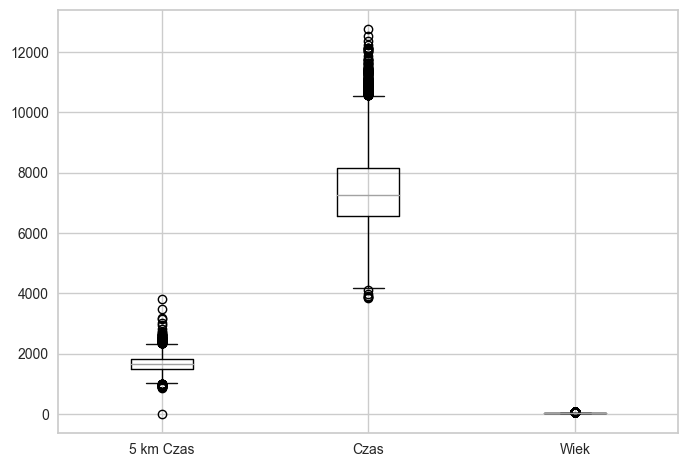

In [19]:
df.boxplot()
plt.show()

### Usuwamy outliers'y

In [20]:
def removing_outliers(df,factor=1.5):

    numeric = df.select_dtypes(include='number')
    cleaned_df = df.copy()
    for col in numeric:
        Q1=cleaned_df[col].quantile(0.25)
        Q3=cleaned_df[col].quantile(0.75)
        IQR=Q3-Q1

        lower_bound=Q1-1.5*IQR
        upper_bound=Q3+1.5*IQR

        cleaned_df=df[~((df[col]<lower_bound) | (df[col]>upper_bound))]

    return cleaned_df
cleaned_df=removing_outliers(df)

#### Wizualizacja outliersów

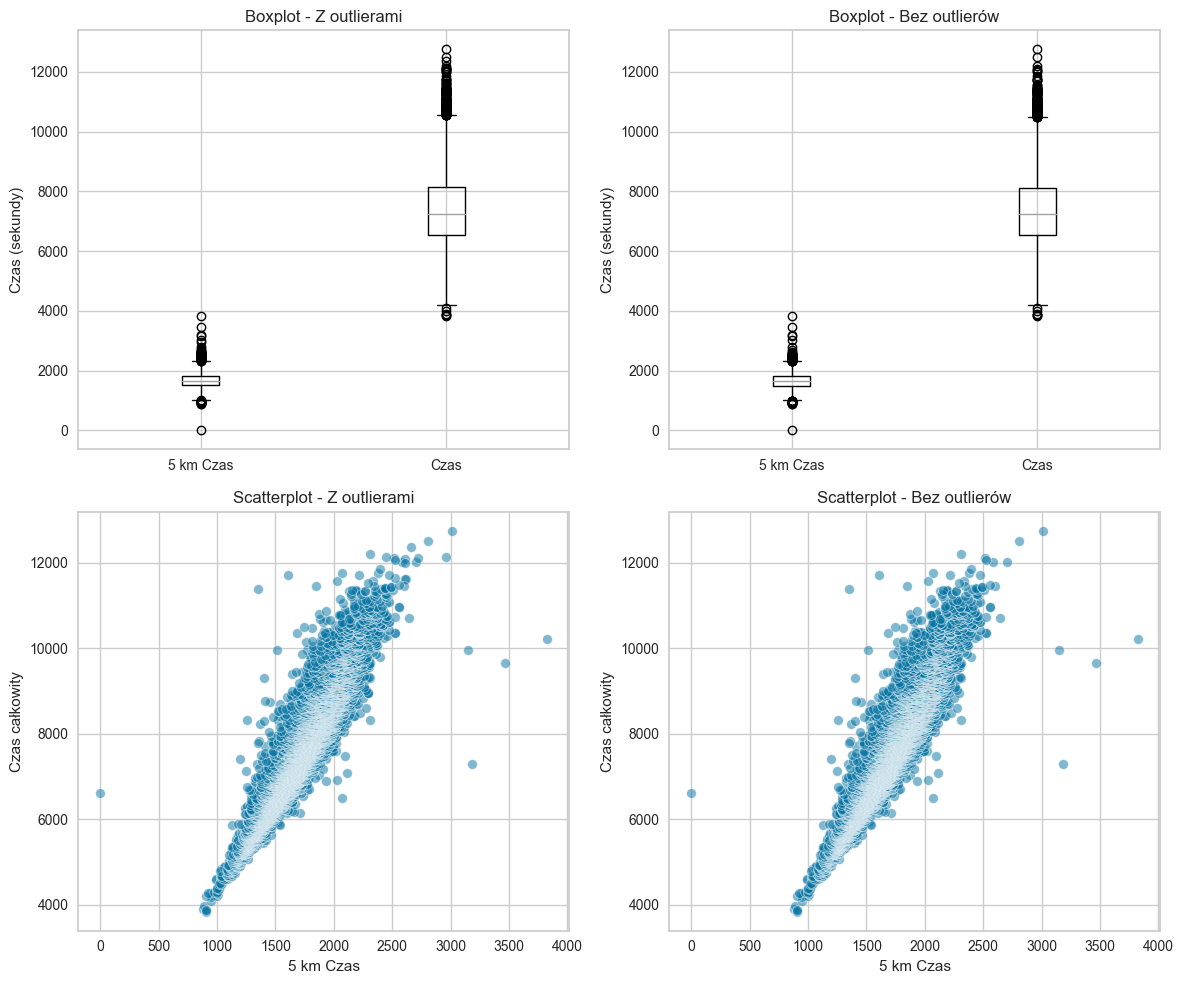

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# # # Górny wiersz - boxploty
df[['5 km Czas', 'Czas']].boxplot(ax=axes[0, 0])
axes[0, 0].set_title('Boxplot - Z outlierami')
axes[0, 0].set_ylabel('Czas (sekundy)')

cleaned_df[['5 km Czas', 'Czas']].boxplot(ax=axes[0, 1])
axes[0, 1].set_title('Boxplot - Bez outlierów')
axes[0, 1].set_ylabel('Czas (sekundy)')

# Dolny wiersz - scatterploty
sns.scatterplot(data=df, x='5 km Czas', y='Czas', ax=axes[1, 0], alpha=0.5)
axes[1, 0].set_title('Scatterplot - Z outlierami')
axes[1, 0].set_xlabel('5 km Czas')
axes[1, 0].set_ylabel('Czas całkowity')

sns.scatterplot(data=cleaned_df, x='5 km Czas', y='Czas', ax=axes[1, 1], alpha=0.5)
axes[1, 1].set_title('Scatterplot - Bez outlierów')
axes[1, 1].set_xlabel('5 km Czas')
axes[1, 1].set_ylabel('Czas całkowity')

plt.tight_layout()
plt.show()

### Sprawdzamy rozkład pod  ewentualną transformację Yeo-Johnson

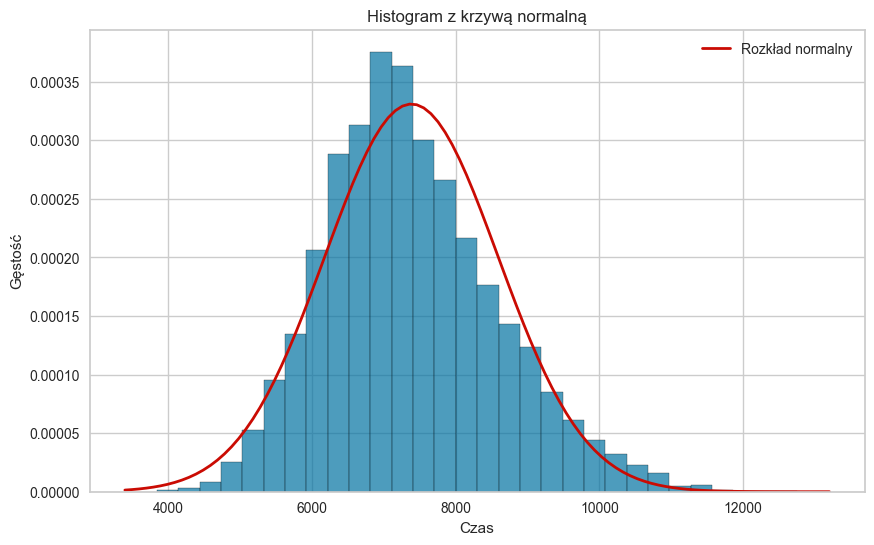

In [22]:
plt.figure(figsize=(10, 6))
plt.hist(cleaned_df['Czas'], bins=30, density=True, alpha=0.7, edgecolor='black')

# Dodaj krzywą normalną
mu = cleaned_df['Czas'].mean()
std = cleaned_df['Czas'].std()
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'r', linewidth=2, label='Rozkład normalny')

plt.xlabel('Czas')
plt.ylabel('Gęstość')
plt.title('Histogram z krzywą normalną')
plt.legend()
plt.show()

## Trenujemy model

In [ ]:
exp =setup(
    data=df,
    target="Czas",
    session_id=3219,
    categorical_features=["Płeć"],
    verbose=True,
)
best_model=exp.compare_models()

Loading ITables v2.7.0 from the init_notebook_mode cell... (need help?)


Loading ITables v2.7.0 from the init_notebook_mode cell... (need help?)


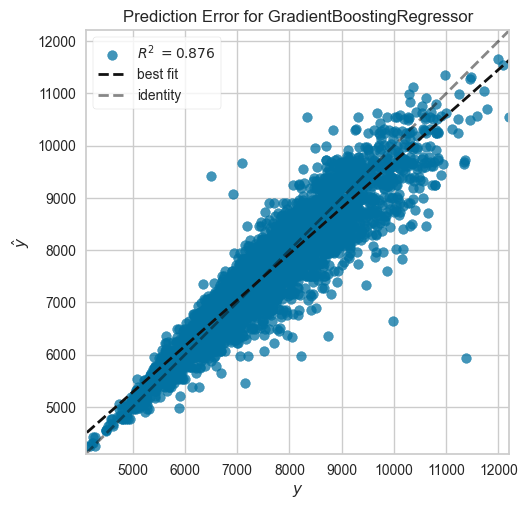

In [33]:
exp.plot_model(best_model, plot='error')

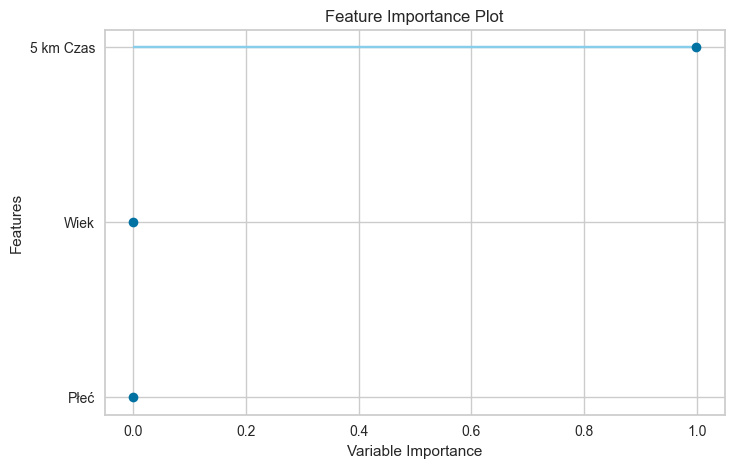

In [34]:
exp.plot_model(best_model,plot="feature")

In [35]:
tuned_model =exp. tune_model(
    best_model,
    optimize='R2',
    choose_better=True
)

Loading ITables v2.7.0 from the init_notebook_mode cell... (need help?)


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Uruchamiam pierwotny model na holdoutsecie

In [36]:
exp.predict_model(best_model)

Loading ITables v2.7.0 from the init_notebook_mode cell... (need help?)


Loading ITables v2.7.0 from the init_notebook_mode cell... (need help?)


### Finalizujemy model

In [37]:
best_final_model = exp.finalize_model(best_model)
best_final_model

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['5 km Czas', 'Wiek'],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=['Płeć'],
                                    transformer=SimpleImputer(strategy='most_frequent'))),
                ('ordinal_encoding',
                 TransformerWrapper(include=['Płeć'],
                                    transformer=OrdinalEncoder(cols=['Płeć'],
                                                               handle_missing='return_nan',
                                                               mapping=[{'col': 'Płeć',
                                                                         'data_type': dtype('O'),
                                                                         'mapping': K      0
M      1
NaN   -1
dtype: int64}]))),
                ('clean_column_names',
                 TransformerWrapper(transformer=CleanColumnNames())),
                ('actual_estimator',
                 GradientBoostingRegressor(random_state=3219))])

#### Zapisuję model lokalnie

In [38]:
exp.save_model(best_final_model,"halfmarathon_model")

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['5 km Czas', 'Wiek'],
                                     transformer=SimpleImputer())),
                 ('categorical_imputer',
                  TransformerWrapper(include=['Płeć'],
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('ordinal_encoding',
                  TransformerWrapper(include=['Płeć'],
                                     transformer=OrdinalEncoder(cols=['Płeć'],
                                                                handle_missing='return_nan',
                                                                mapping=[{'col': 'Płeć',
                                                                          'data_type': dtype('O'),
                                                                          'mapping': K      0
 M      1
 NaN   -1
 dtype: int64}]))),
          

### Zapisuję model do DigitalOcean Spaces

In [41]:
try:
    client.upload_file('polmaraton_model.pkl', BUCKET_NAME, 'stocks/polmaraton_model.pkl')
    print("Model został pomyślnie wysłany!")
except Exception as e:
    print(f"Wystąpił błąd: {e}")

Model został pomyślnie wysłany!
